---
# OpenCV 라이브러리

**OpenCV(Open Source Computer Vision Library)** 는 이미지와 영상 데이터를 처리하기 위한 **대표적인 컴퓨터 비전(Computer Vision) 라이브러리**입니다.

OpenCV는 원래 **C++ 기반**으로 개발된 고성능 라이브러리이며 현재는 **Python, Java** 등 다양한 언어에서 사용할 수 있는 인터페이스를 제공합니다.

이미지 처리, 영상 분석, 객체 인식, 얼굴 인식 등 **컴퓨터가 시각 정보를 이해하도록 만드는 기술**을 구현할 때 널리 사용됩니다.

* 설치 명령어 : `pip install opencv-python`
    * 컴퓨터가 사진이나 영상을 보고 이해할 수 있게 해주는 도구 세트를 설치하는 과정입니다.

---

## 1. OpenCV 역할

우리가 만든 인공지능 모델은 '숫자'만 이해할 수 있습니다.
하지만 예로 `바지.png`는 '이미지 파일'입니다.
OpenCV(`cv2`)는 그 사이에서 **번역가** 역할을 수행합니다.

* **파일 읽기:** 이미지 파일을 픽셀 값 배열로 변환합니다.
* **크기 조절 (Resize):** 모델이 요구하는 입력 크기로 이미지를 변환합니다.
* **색상 변환:** 컬러 이미지를 흑백으로 바꾸거나, 배경과 물체의 색을 반전시킵니다.
* **필터링:** 사진의 노이즈를 제거하거나 선을 더 선명하게 만듭니다.

---

### 2. import cv2

라이브러리 공식 이름은 **OpenCV** (Open Source Computer Vision)이지만, 파이썬 코드에서 불러올 때는 `import cv2`라고 씁니다.

* **cv**: Computer Vision의 약자입니다.
* **2**: C++ API의 인터페이스 버전을 의미합니다. 현재는 버전 4 이상이 널리 쓰이지만, 하위 호환성을 위해 관습적으로 `cv2`라는 이름을 계속 사용합니다.

---

### 3. 실생활 활용 사례

우리가 지금 하는 '패션 아에팀 분류'외에도 다양한 분야에서 핵심 기술로 쓰입니다.

1. **자율주행 자동차**: 카메라로 도로의 차선, 표지판, 보행자를 인식합니다.
2. **얼굴 인식**: 스마트폰 잠금 해제나 카메라 필터 앱의 핵심 기술입니다.
3. **지능형 CCTV** : 사람이 쓰러지거나 이상 행동을 하는 장면을 자동으로 감지합니다.
4. **의료 영상**: MRI나 X-ray 사진에서 질병 부위를 찾아내기 위한 전처리를 담당합니다.

---

In [1]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/40.2 MB 25.0 MB/s eta 0:00:02
   ------------ --------------------------- 12.6/40.2 MB 32.9 MB/s eta 0:00:01
   --------------------- ------------------ 22.0/40.2 MB 36.6 MB/s eta 0:00:01
   ------------------------------- -------- 32.0/40.2 MB 39.0 MB/s eta 0:00:01
   ---------------------------------------  40.1/40.2 MB 40.5 MB/s eta 0:00:01
   ---------------------------------------- 40.2/40.2 MB 38.7 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


---
OpenCV 기본 예제 1: 이미지 읽기와 변환

OpenCV(cv2)는 이미지를 읽을 때 RGB가 아니라 BGR 순서로 읽습니다.

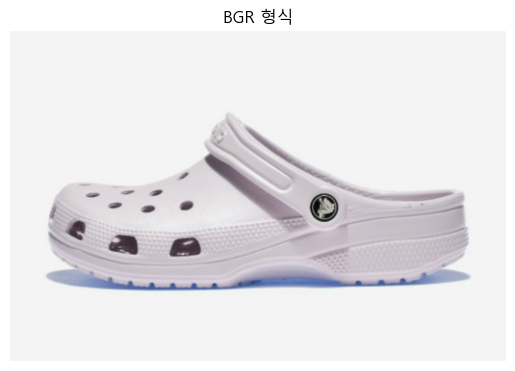

In [3]:
import cv2
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 이미지 읽기
img = cv2.imread("./data/crocs.png")

plt.imshow(img)
plt.title("BGR 형식")
plt.axis("off")
plt.show()

---
BGR -> RGB로 변경하기

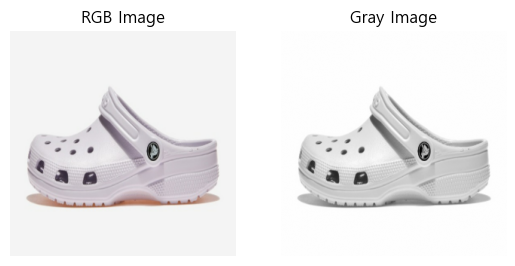

In [4]:
# 1. 이미지 읽기
img = cv2.imread("./data/crocs.png")

# 2. 이미지가 정상적으로 읽혔는지 확인
if img is None:
    print("이미지를 읽을 수 없습니다. 파일 경로를 확인하세요")
else:
    # 3. OpenCV는 기본적으로 BGR 형식으로 읽기 때문에 RGB로 변환
    # BGR -> RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 4. 크기 조정
    img_resized = cv2.resize(img_rgb, (300, 300))

    # 5. RGB -> 흑백
    img_gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

    # 6. 출력
    plt.subplot(1, 2, 1)
    plt.imshow(img_resized)
    plt.title("RGB Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_gray , cmap="gray")
    plt.title("Gray Image")
    plt.axis("off")
    plt.show()

---
OpenCV 기본 예제 2: 이미지 저장까지 해보기

In [5]:
import cv2

img = cv2.imread("./data/crocs.png")

if img is None:
    print("이미지를 읽을 수 없습니다.")
else:
    # 흑백 변환
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 저장
    cv2.imwrite("sample_gray.jpg", gray)

    print("흑백 이미지로 저장 완료: sample_gary.jpg")

흑백 이미지로 저장 완료: sample_gary.jpg


---
### OpenCV 기본 예제 3: 28x28로 바꾸기

cv2.imread(파일경로, 읽기모드)

| 읽기 모드 | 코드 | 의미 | 결과 이미지 형태 |
| :--- | :--- | :--- | :--- |
| 컬러 읽기 | `cv2.IMREAD_COLOR` | 이미지를 **컬러(BGR)** 로 읽습니다. (기본값) | `(height, width, 3)` |
| 흑백 읽기 | `cv2.IMREAD_GRAYSCALE` | 이미지를 **흑백(Gray)** 으로 읽습니다. | `(height, width)` |


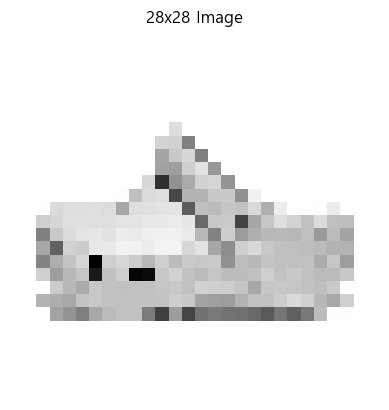

In [6]:
import cv2
import matplotlib.pyplot as plt

filepath = "./data/crocs.png"

img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

if img is None:
    print("이미지를 읽을 수 없습니다.")
else:
    img_resized = cv2.resize(img, (28,28))

    plt.imshow(img_resized, cmap="gray")
    plt.title("28x28 Image")
    plt.axis("off")
    plt.show()

---
이미지 파일을 읽어서 딥러닝 모델이 입력으로 사용할 수 있는 형태로 준비하고, 모델이 실제로 보게 될 이미지를 확인하기 위한 전처리 과정입니다.

* 이미지 파일 $\rightarrow$ 모델 입력 데이터로 변환 $\rightarrow$ 화면에 확인
* FashionMNIST 데이터는 다음과 같은 형태입니다.

    | 색 | 픽셀 값 |
    | :--- | :--- |
    |검정(배경) | 0 |
    | 흰색(물체) | 255 |

    만약 흰색 배경인 경우에는 255 - 기존 픽셀값 이어야 합니다.

---
1. 파일 존재 여부 확인

2. 이미지 읽기

3. 크기 조정

4. 색상 반전(배경이 흰색일 때)

5. 데이터 전처리(정규화 + 차원 확장)

6. 모델 예측

7. 확률이 가장 큰 값을 찾아 출력형식에 맞게 작성

In [7]:
import keras

In [8]:
model = keras.models.load_model('best-cnn-model.keras')

In [9]:
def predict_image(filepath, background="black"):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt
    import os       # 파일 존재 여부 확인용

    # 1. 파일 존재 여부 확인
    if not os.path.exists(filepath):
        print(f"오류 : '{filepath}'파일이 존재하지 않습니다. 경로를 다시 확인해 주세요. ")
        return  # 함수 즉시 중단
    
    # 2. 이미지를 흑백(그레이스 스케일)로 읽기
    img = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

    # 이미지 파일은 있지만, OpenCV가 읽지 못하는 경우 (예: 손상된 파일이나 한글 경로 문제)
    if img is None:
        print("오류 : 이미지를 읽어올 수 없습니다. 파일 형식이나 한글 경로 여부를 확인하세요.")
        return  # 함수 즉시 중단
    
    # 3. 크기 조정 (28x28)
    img_resized = cv2.resize(img, (28, 28))
    
    # 4. 색상 반전 (배경이 흰색일 경우, 모델이 좋아하는 검은 배경으로 뒤집기)
    if background == "white":
        img_resized = 255 - img_resized
    
    # 5. 데이터 전처리 (정규화 + 차원 확장)
    img_scaled = img_resized / 255.0
    img_input = img_scaled.reshape(1, 28, 28, 1) 
    
    # 6. 모델 예측
    # model 객체는 함수 밖에서 이미 생성되어 있어야 합니다.
    preds = model.predict(img_input)
    
    

    classes = ['티셔츠', '바지', '스웨터', '드레스', '코트', 
                    '샌달', '셔츠', '스니커즈', '가방', '앵클 부츠']
    
    # 7. 모델이 실제로 본 모습 확인
    plt.imshow(img_resized, cmap='gray')
    plt.title("image")
    plt.show()
    
    best_idx = np.argmax(preds) 

    # 8. 최종 결과 출력
    print(f"결과: {classes[best_idx]} (확률: {preds[0][best_idx]*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


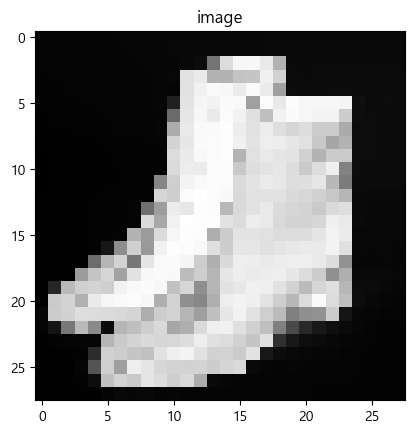

결과: 앵클 부츠 (확률: 89.51%)


In [11]:
predict_image("./data/boot2.png", background="white")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


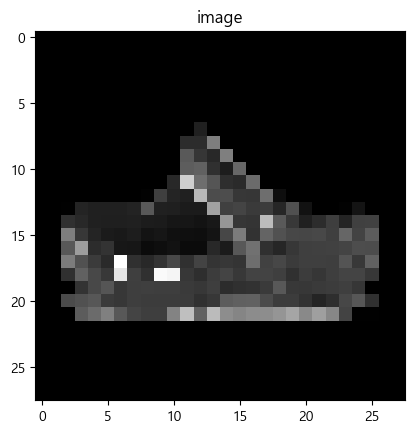

결과: 샌달 (확률: 73.43%)


In [12]:
predict_image("./data/crocs.png", background="white")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


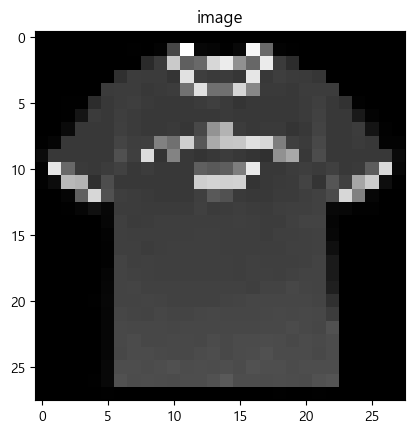

결과: 티셔츠 (확률: 68.94%)


In [13]:
predict_image("./data/tshirt.png", background="white")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


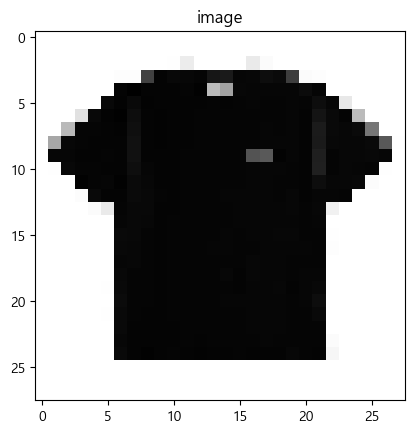

결과: 가방 (확률: 100.00%)


In [14]:
predict_image("./data/tshirt2.png", background="white")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


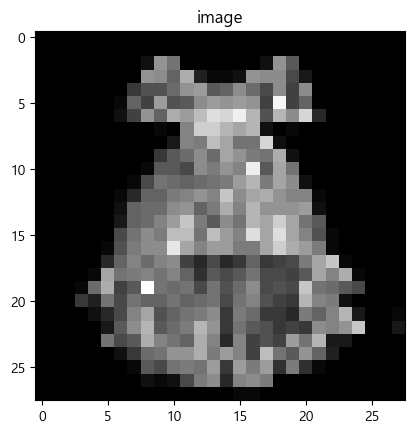

결과: 드레스 (확률: 53.85%)


In [15]:
predict_image("./data/dress.png", background="white")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


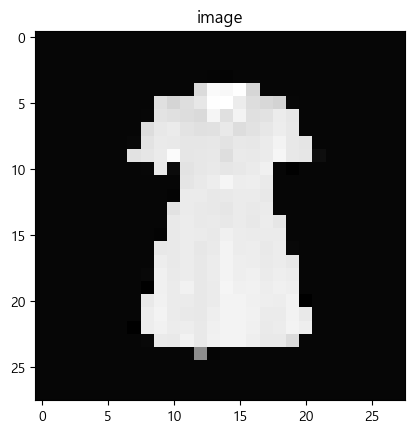

결과: 드레스 (확률: 99.02%)


In [16]:
predict_image("./data/dress2.jpg", background="white")